In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind, t

In [6]:
data=pd.read_csv('superstore_dataset.csv', encoding='latin-1')
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
#Are there any missing values in the dataset?
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [ ]:
df.drop_duplicates(inplace=True)

New York Sales Mean: 275.59953102836874
California Sales Mean: 228.72945102448776
New York Profit Mean: 65.63701117021277
California Profit Mean: 38.17160774612694


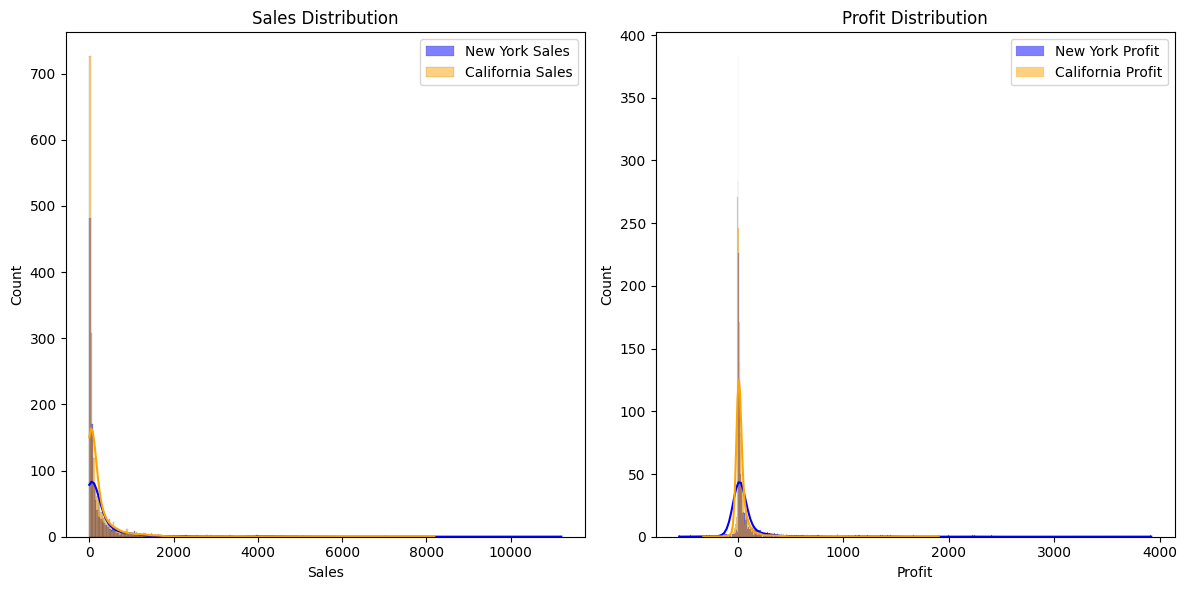

In [9]:
ny_sales=data[data['State']=='New York']['Sales']
california_sales=data[data['State']=='California']['Sales']
ny_profit=data[data['State']=='New York']['Profit']
california_profit=data[data['State']=='California']['Profit']

print("New York Sales Mean:", ny_sales.mean())
print("California Sales Mean:", california_sales.mean())
print("New York Profit Mean:", ny_profit.mean())
print("California Profit Mean:", california_profit.mean())

#Graph the distribution of sales and profit for both states
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(ny_sales, kde=True, color='blue', label='New York Sales')
sns.histplot(california_sales, kde=True, color='orange', label='California Sales')
plt.title('Sales Distribution')
plt.legend()
plt.subplot(1, 2, 2)
sns.histplot(ny_profit, kde=True, color='blue', label='New York Profit')
sns.histplot(california_profit, kde=True, color='orange', label='California Profit')
plt.title('Profit Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
#Find an outstanding customer in New York
customer_sales = data[data['State'] == 'New York'].groupby('Customer Name')['Sales'].sum()
print("New York Customers")
print(customer_sales.sort_values(ascending=False).head())
top_customer = customer_sales.sort_values(ascending=False).index[0]
print(f"Outstanding Customer in New York: {top_customer} with Sales: {customer_sales[top_customer]}")

New York Customers
Customer Name
Tom Ashbrook        13723.498
Peter Fuller         7678.228
Seth Vernon          7359.918
Tom Boeckenhauer     6999.960
Greg Tran            6712.744
Name: Sales, dtype: float64
Outstanding Customer in New York: Tom Ashbrook with Sales: 13723.498000000001


C:\Users\typal\AppData\Local\Temp\ipykernel_11800\2771041712.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_state.index, y=profit_by_state.values, palette='viridis')


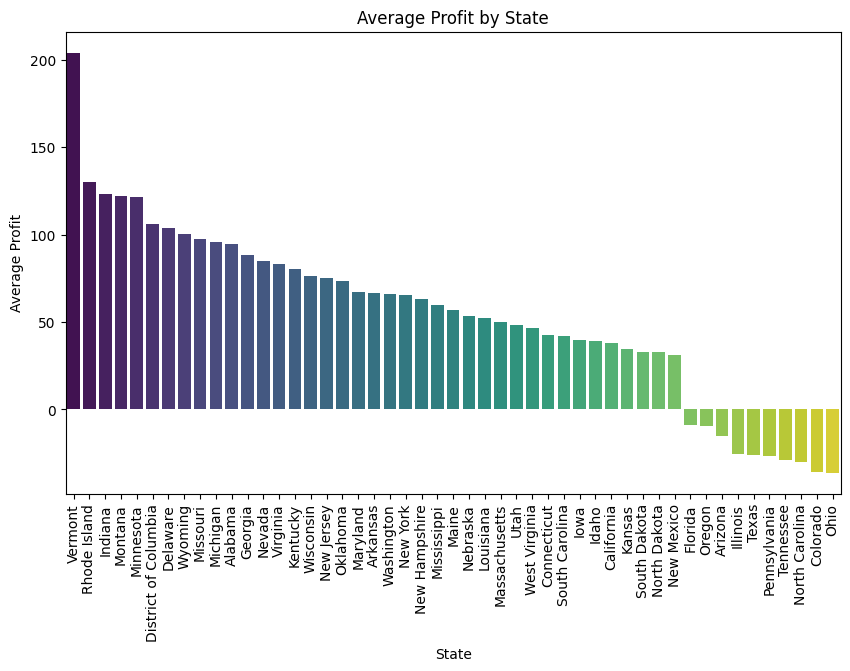

In [15]:
#Are there any differences among states in profitability?
profit_by_state = data.groupby('State')['Profit'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=profit_by_state.index, y=profit_by_state.values, palette='viridis')
plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit')
plt.xticks(rotation=90)
plt.show()


From the above graph, we can see that there are differences in profitability among states. Some states have higher average profits than others, which could be due to various factors such as market demand, competition, or operational efficiency.For example in Vermont and Rhode Island, the profits are very high.Other states however, have a negative profit. This means stores in these states are spending more than they earn on average. 

In [18]:
neg_profit_states = profit_by_state[profit_by_state < 0].index.tolist()
print("States with Negative Profit:")
print(neg_profit_states)

States with Negative Profit:
['Florida', 'Oregon', 'Arizona', 'Illinois', 'Texas', 'Pennsylvania', 'Tennessee', 'North Carolina', 'Colorado', 'Ohio']


In [20]:
#Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
customer_profit = data.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).reset_index()
customer_profit['Cumulative Profit'] = customer_profit['Profit'].cumsum()
customer_profit['Cumulative Profit Percentage'] = customer_profit['Cumulative Profit'] / customer_profit['Profit'].sum() * 100
customer_profit['Customer Percentage'] = (customer_profit.index + 1) / len(customer_profit) * 100

threshold_row = customer_profit[customer_profit['Cumulative Profit Percentage'] >= 80].iloc[0]
threshold_customer_percentage = threshold_row['Customer Percentage']

print(f"80% of profit is driven by the top {threshold_customer_percentage:.1f}% of customers")
print(f"That's {customer_profit[customer_profit['Cumulative Profit Percentage'] <= 80].shape[0]} customers "
      f"out of {len(customer_profit)} total")

80% of profit is driven by the top 19.3% of customers
That's 152 customers out of 793 total


AttributeError: module 'matplotlib.pyplot' has no attribute 'ticker'

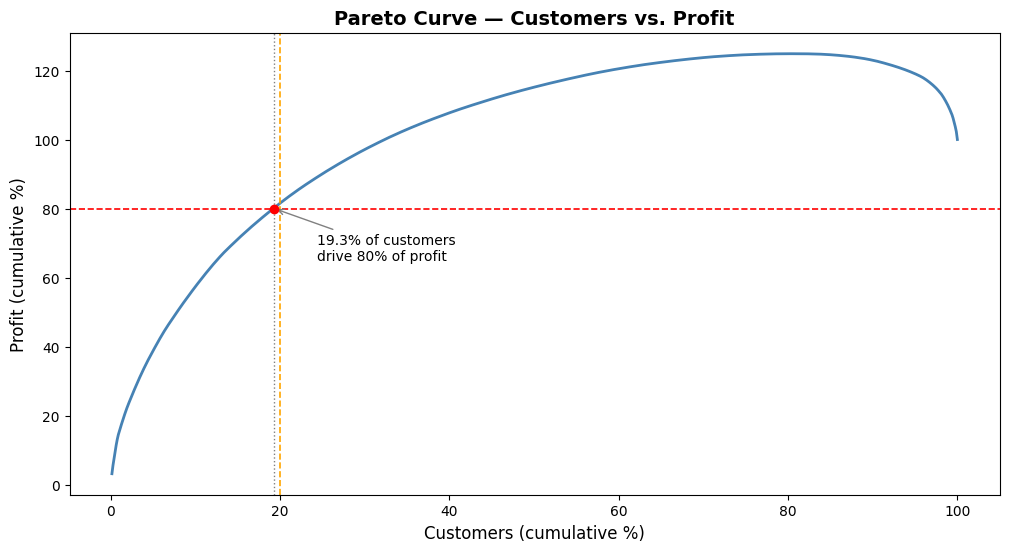

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(customer_profit["Customer Percentage"], customer_profit["Cumulative Profit Percentage"],
        color="steelblue", linewidth=2, label="Cumulative Profit %")

# Reference lines
ax.axhline(80, color="red",   linestyle="--", linewidth=1.2, label="80% Profit")
ax.axvline(20, color="orange",linestyle="--", linewidth=1.2, label="20% Customers")

# Intersection marker
ax.axvline(threshold_customer_percentage, color="gray", linestyle=":", linewidth=1)
ax.scatter([threshold_customer_percentage], [80], color="red", zorder=5)
ax.annotate(f"{threshold_customer_percentage:.1f}% of customers\ndrive 80% of profit",
            xy=(threshold_customer_percentage, 80),
            xytext=(threshold_customer_percentage + 5, 65),
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=10)

ax.set_xlabel("Customers (cumulative %)", fontsize=12)
ax.set_ylabel("Profit (cumulative %)",    fontsize=12)
ax.set_title("Pareto Curve — Customers vs. Profit", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(plt.ticker.PercentFormatter())
ax.yaxis.set_major_formatter(plt.ticker.PercentFormatter())
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
#Top 20 cities by sales and profit
top_cities_sales = data.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
top_cities_profit = data.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

print("Top 20 Cities by Sales:")
print(top_cities_sales)
print("\nTop 20 Cities by Profit:")
print(top_cities_profit)

Top 20 Cities by Sales:
City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64

Top 20 Cities by Profit:
City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1

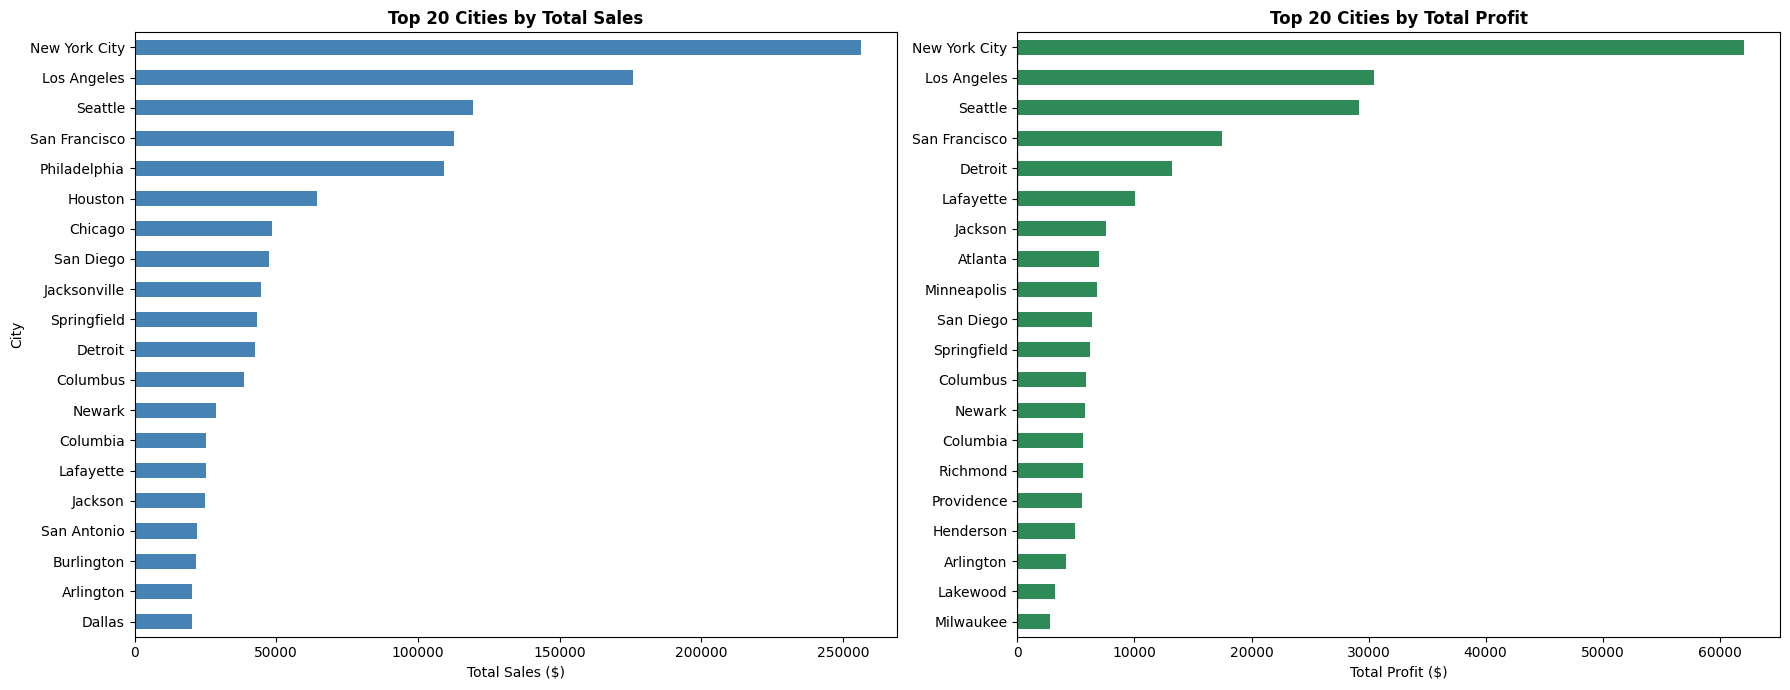

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Sales ---
top_cities_sales.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Cities by Total Sales', fontweight='bold')
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_ylabel('City')

# --- Profit ---
colors = ['tomato' if x < 0 else 'seagreen' for x in top_cities_profit.sort_values()]
top_cities_profit.sort_values().plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Top 20 Cities by Total Profit', fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].set_ylabel('')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [24]:
# Combine into one DataFrame
city_summary = pd.DataFrame({
    'Sales':  top_cities_sales,
    'Profit': top_cities_profit
}).dropna()  # keep only cities in both top 20s

city_summary['Profit_Margin_%'] = (city_summary['Profit'] / city_summary['Sales'] * 100).round(2)
city_summary = city_summary.sort_values('Profit_Margin_%', ascending=False)

print(city_summary)


                    Sales      Profit  Profit_Margin_%
City                                                  
Lafayette       25036.200  10018.3876            40.02
Detroit         42446.944  13181.7908            31.05
Jackson         24963.858   7581.6828            30.37
Seattle        119540.742  29156.0967            24.39
New York City  256368.161  62036.9837            24.20
Columbia        25283.324   5606.1167            22.17
Arlington       20214.532   4169.6969            20.63
Newark          28576.119   5793.7588            20.27
Los Angeles    175851.341  30440.7579            17.31
San Francisco  112669.092  17507.3854            15.54
Columbus        38706.243   5897.1013            15.24
Springfield     43054.342   6200.6974            14.40
San Diego       47521.029   6377.1960            13.42


In [27]:
import scipy.stats as stats
# Filter raw data to top 20 sales cities
top20_city_names = top_cities_sales.index
df_top20 = data[data['City'].isin(top20_city_names)]

# Run ANOVA
groups = [group['Profit'].values for _, group in df_top20.groupby('City')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"ANOVA F-statistic : {f_stat:.3f}")
print(f"P-value           : {p_value:.4f}")
print()
if p_value < 0.05:
    print("✅ Significant differences in profitability across cities (p < 0.05)")
else:
    print("❌ No significant difference detected")


ANOVA F-statistic : 9.973
P-value           : 0.0000

✅ Significant differences in profitability across cities (p < 0.05)


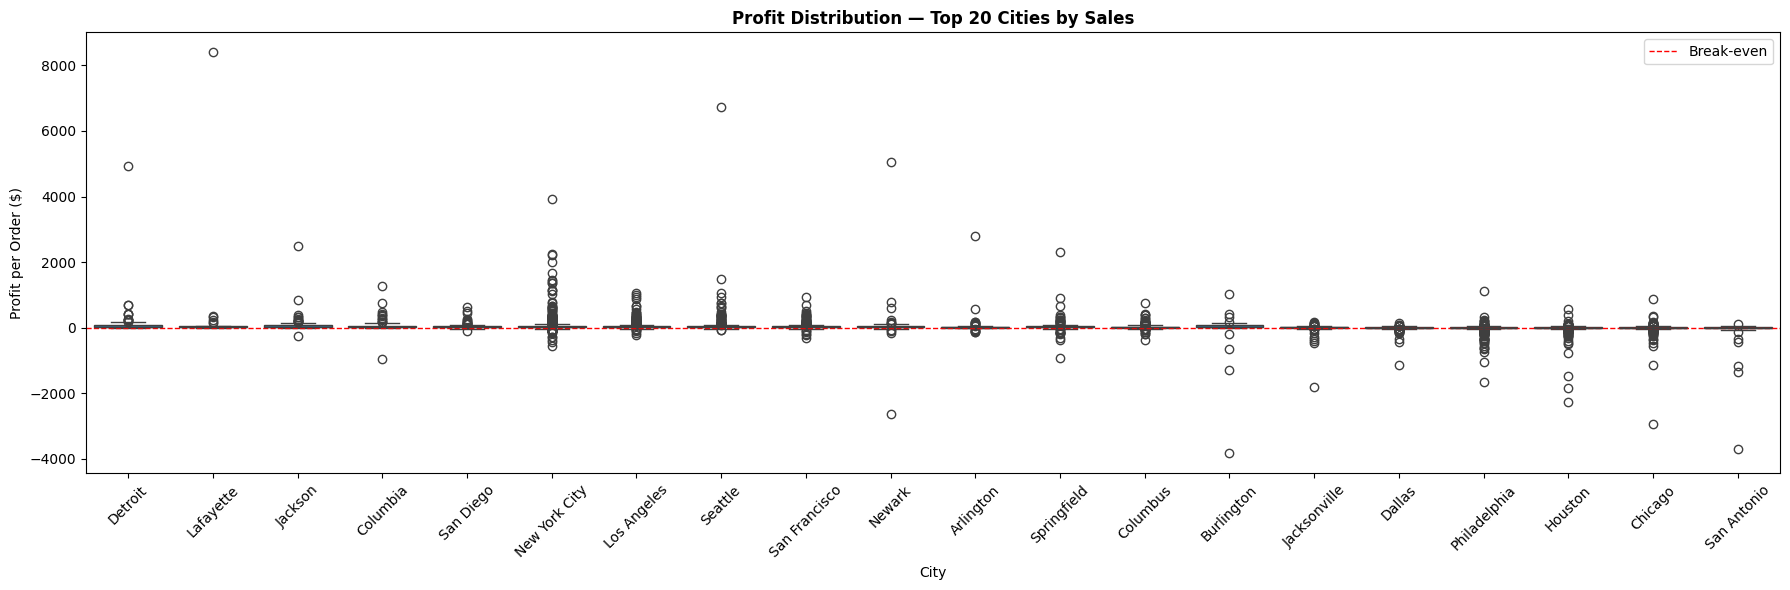

In [29]:
city_order = (
    df_top20.groupby('City')['Profit']
    .median()
    .sort_values(ascending=False)
    .index.tolist()  # seaborn needs a list, not an Index
)

fig, ax = plt.subplots(figsize=(18, 6))

sns.boxplot(
    data=df_top20,
    x='City',
    y='Profit',
    order=city_order,
    ax=ax
)

ax.set_title('Profit Distribution — Top 20 Cities by Sales', fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Profit per Order ($)')
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
#Top 20 customers by sales
top_customers_sales = data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)
print("Top 20 Customers by Sales:")
print(top_customers_sales)

Top 20 Customers by Sales:
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


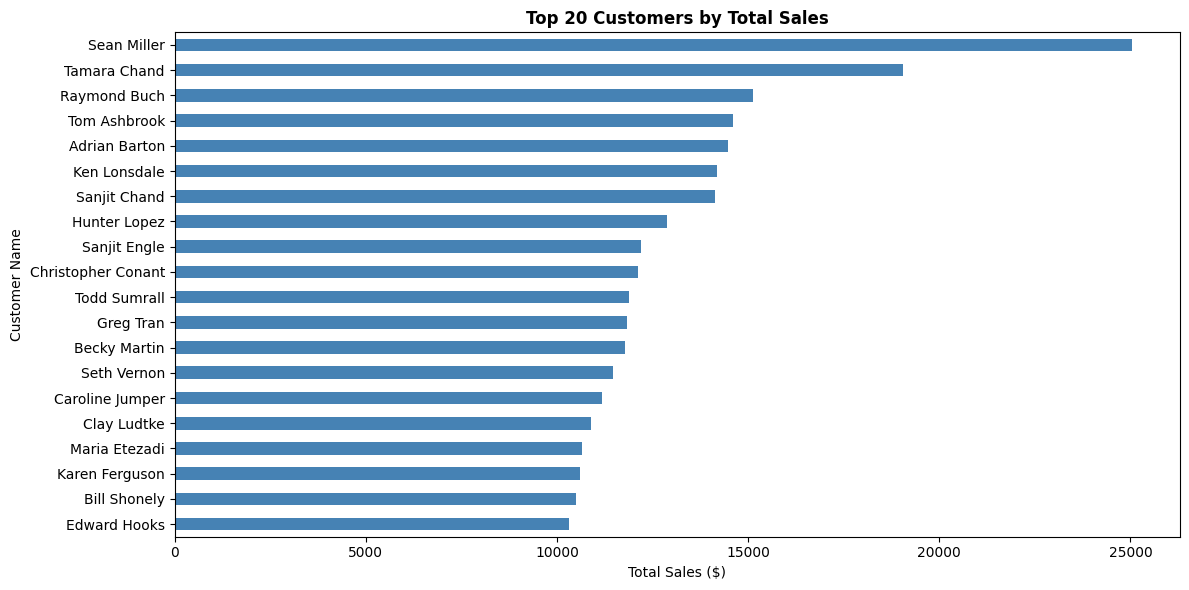

In [31]:
#plot top 20 customers by sales
plt.figure(figsize=(12, 6))
top_customers_sales.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Customers by Total Sales', fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.show()

80% of Sales is driven by the top 49.9% of customers
That's 395 customers out of 793 total


AttributeError: module 'matplotlib.pyplot' has no attribute 'mtick'

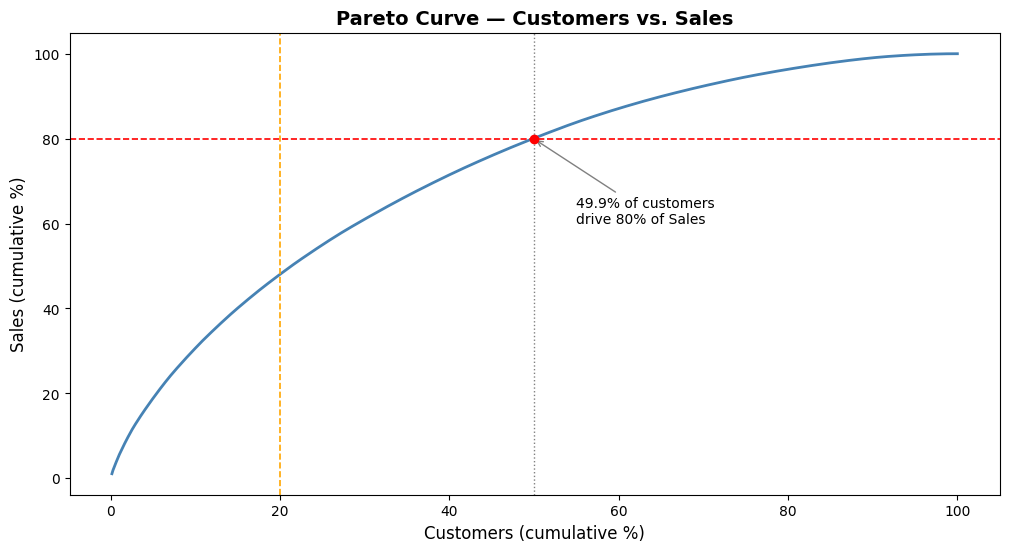

In [34]:
# ── Pareto: Cumulative Sales by Customer ──────────────────────────────────────

# 1. Aggregate ALL customers (not just top 20)
customer_sales = (
    data.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Cumulative % columns
total_customers = len(customer_sales)
customer_sales['cumulative_sales']     = customer_sales['Sales'].cumsum()
customer_sales['cumulative_sales_pct'] = customer_sales['cumulative_sales'] / customer_sales['Sales'].sum() * 100
customer_sales['customer_pct']         = (customer_sales.index + 1) / total_customers * 100

# 3. Find where cumulative sales crosses 80%
threshold_row          = customer_sales[customer_sales['cumulative_sales_pct'] >= 80].iloc[0]
threshold_customer_pct = threshold_row['customer_pct']
threshold_customer_n   = customer_sales[customer_sales['cumulative_sales_pct'] <= 80].shape[0]

print(f"80% of Sales is driven by the top {threshold_customer_pct:.1f}% of customers")
print(f"That's {threshold_customer_n} customers out of {total_customers} total")

# 4. Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(customer_sales['customer_pct'], customer_sales['cumulative_sales_pct'],
        color='steelblue', linewidth=2, label='Cumulative Sales %')

# Reference lines
ax.axhline(80, color='red',    linestyle='--', linewidth=1.2, label='80% Sales')
ax.axvline(20, color='orange', linestyle='--', linewidth=1.2, label='20% Customers')

# Intersection marker
ax.axvline(threshold_customer_pct, color='gray', linestyle=':', linewidth=1)
ax.scatter([threshold_customer_pct], [80], color='red', zorder=5)
ax.annotate(
    f"{threshold_customer_pct:.1f}% of customers\ndrive 80% of Sales",
    xy=(threshold_customer_pct, 80),
    xytext=(threshold_customer_pct + 5, 60),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=10
)

ax.set_xlabel('Customers (cumulative %)', fontsize=12)
ax.set_ylabel('Sales (cumulative %)',     fontsize=12)
ax.set_title('Pareto Curve — Customers vs. Sales', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.mtick.PercentFormatter())
ax.yaxis.set_major_formatter(plt.mtick.PercentFormatter())
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Pareto Analysis — Customers & Profit

The analysis confirms the Pareto Principle for **profit**:  
- The top **19.3% of customers** (152 out of 793) drive **80% of total profit**  
- This closely matches the classic 80/20 rule, suggesting a small, high-value customer segment is disproportionately responsible for profitability  
- **Implication:** Retaining and nurturing these ~152 customers should be a top priority — losing even a few could significantly impact overall profit

## Pareto Analysis — Customers & Sales

The Pareto Principle does **not** hold for **sales**:  
- It takes the top **49.9% of customers** (395 out of 793) to reach 80% of total sales  
- Sales are distributed much more evenly across the customer base than profit is  
- **Key insight:** High sales volume does not equal high profit. Many customers generate significant revenue but low (or negative) margins — likely due to discounting. This reinforces the importance of tracking profit, not just sales.

## Strategic Recommendations — States & Cities to Prioritize

### Summary of Key Findings

| Dimension | Finding |
|---|---|
| Top sales state | California |
| Top profit state | New York (higher avg profit: $65.6 vs $38.2) |
| Loss-making states | Texas, Illinois, Ohio, Pennsylvania, Florida, and 5 others |
| Top city by sales | New York City ($256K) |
| Top city by profit margin | Lafayette (40%), Detroit (31%), Jackson (30%) |
| Unprofitable top-sales cities | Philadelphia, Houston (negative or near-zero margins) |
| Pareto — Profit | 19.3% of customers drive 80% of profit ✅ |
| Pareto — Sales | 49.9% of customers needed for 80% of sales ❌ |

---

### 🟢 States to Double Down On

**New York**
- Highest average profit per order ($65.6) among major states
- Home to top customer Tom Ashbrook ($13.7K in sales)
- New York City alone generates $256K in sales at a 24.2% margin
- **Action:** Increase marketing spend, prioritize account management for top customers

**Washington (Seattle)**
- High sales ($119K) with a strong 24.4% profit margin
- Consistent, healthy profitability — low risk, high return
- **Action:** Scale existing strategy, good candidate for expansion campaigns

**California**
- Highest total sales volume but lower profit margin than New York ($38.2 avg)
- Large market — worth retaining but requires margin discipline
- **Action:** Review discount practices, focus on high-margin product categories

---

### 🔴 States to Fix Before Investing

**Texas, Illinois, Pennsylvania, Ohio, Florida**
- All show **negative average profit** — every marketing dollar spent here deepens losses
- **Action:** Do not increase marketing spend. First audit discount policies and product mix. Only reinvest once profitability is restored.

---

### 🏙️ Cities to Prioritize

**Invest more:**
- **New York City** — #1 in both sales and profit in absolute terms
- **Seattle** — strong margin, consistent performance
- **Lafayette, Detroit, Jackson** — small markets but exceptional profit margins (30–40%)

**Fix or deprioritize:**
- **Philadelphia** — #5 in sales but poor profitability; heavy discounting likely
- **Houston** — similar pattern; high volume, weak margins

---

### Customer Strategy (Pareto-driven)

- The **top ~150 customers** drive 80% of profit — identify them, assign account managers, protect retention
- Sales are spread across ~400 customers for the same 80% threshold — broad acquisition campaigns are less efficient than retention of the profitable core
- **Outstanding customer to protect:** Tom Ashbrook (New York, $13.7K sales)